# DOC-ANNs — Model Performance (Figure 4)

This notebook reproduces **Figure 4** from Bonelli et al. (2022): scatter plots comparing model-derived vs. measured DOC for both DOC-ANNa and DOC-ANNb, over training and validation datasets.

> Bonelli et al. (2022), *Remote Sensing of Environment*, 281, 113227. https://doi.org/10.1016/j.rse.2022.113227

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Reproduce the exact style of Figure 4 from Bonelli et al. (2022)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.linewidth": 1.2,
})

## Load train/validation datasets

In [2]:
# DOC-ANNa datasets (coastal waters, OWC classes 1-9)
ANNa_train = pd.read_csv("../data/DOCANNa_Train.csv")
ANNa_val   = pd.read_csv("../data/DOCANNa_Val.csv")

# DOC-ANNb datasets (open ocean, OWC classes 10-17)
ANNb_train = pd.read_csv("../data/DOCANNb_Train.csv")
ANNb_val   = pd.read_csv("../data/DOCANNb_Val.csv")

print(f"DOC-ANNa: {len(ANNa_train)} train, {len(ANNa_val)} val")
print(f"DOC-ANNb: {len(ANNb_train)} train, {len(ANNb_val)} val")

DOC-ANNa: 109 train, 47 val
DOC-ANNb: 215 train, 93 val


## Compute statistics

In [17]:
def compute_stats(df):
    obs = df["DOC_in_situ"].values
    est = df["DOC_estimated"].values
    n    = len(obs)
    rmsd = np.sqrt(np.mean((obs - est)**2))
    mapd = np.mean(np.abs(obs - est) / obs) * 100
    mb   = np.mean(est - obs)
    r2   = np.corrcoef(obs, est)[0, 1]**2
    return {"N": n, "RMSD": rmsd, "MAPD": mapd, "MB": mb, "R2": r2}

stats_ANNa_train = compute_stats(ANNa_train)
stats_ANNa_val   = compute_stats(ANNa_val)
stats_ANNb_train = compute_stats(ANNb_train)
stats_ANNb_val   = compute_stats(ANNb_val)

for name, s in [("ANNa Train", stats_ANNa_train), ("ANNa Val", stats_ANNa_val),
                ("ANNb Train", stats_ANNb_train), ("ANNb Val", stats_ANNb_val)]:
    print(f"{name}: N={s['N']}, RMSD={s['RMSD']:.2f}, MAPD={s['MAPD']:.2f}%, MB={s['MB']:.2f}, R²={s['R2']:.3f}")

ANNa Train: N=109, RMSD=5.83, MAPD=6.81%, MB=0.27, R²=0.403
ANNa Val: N=47, RMSD=6.23, MAPD=7.55%, MB=0.77, R²=0.178
ANNb Train: N=215, RMSD=5.59, MAPD=6.54%, MB=1.08, R²=0.524
ANNb Val: N=93, RMSD=5.96, MAPD=7.27%, MB=0.69, R²=0.275


## Figure 4 — Scatter plots (training and validation)

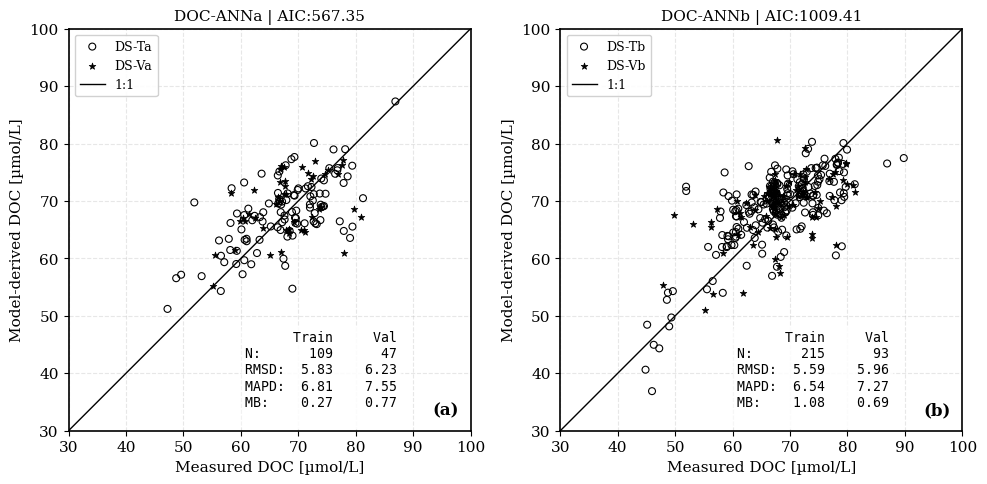

Figure saved to figures/Figure4_model_performance.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

models = [
    ("DOC-ANNa | AIC:567.35", ANNa_train, ANNa_val, stats_ANNa_train, stats_ANNa_val, axes[0], "(a)"),
    ("DOC-ANNb | AIC:1009.41", ANNb_train, ANNb_val, stats_ANNb_train, stats_ANNb_val, axes[1], "(b)"),
]

for title, train_df, val_df, s_tr, s_v, ax, label in models:
    # Data
    ax.scatter(train_df.DOC_in_situ, train_df.DOC_estimated,
               s=25, facecolors="none", edgecolors="k", linewidths=0.8,
               label="DS-Ta" if "ANNa" in title else "DS-Tb", zorder=3)
    ax.scatter(val_df.DOC_in_situ, val_df.DOC_estimated,
               s=25, marker="*", c="k", linewidths=0.5,
               label="DS-Va" if "ANNa" in title else "DS-Vb", zorder=4)

    # 1:1 line
    lims = [30, 100]
    ax.plot(lims, lims, "k-", linewidth=1, label="1:1", zorder=2)

    # Stats box — train | val
    textstr = (
        f"      Train     Val\n"
        f"N:   {s_tr['N']:>6}   {s_v['N']:>5}\n"
        f"RMSD: {s_tr['RMSD']:>5.2f}    {s_v['RMSD']:>4.2f}\n"
        f"MAPD: {s_tr['MAPD']:>5.2f}    {s_v['MAPD']:>4.2f}\n"
        f"MB:   {s_tr['MB']:>5.2f}    {s_v['MB']:>4.2f}\n"
    )
    ax.text(0.44, 0.25, textstr, transform=ax.transAxes,
            fontsize=9.5, verticalalignment="top",
            fontfamily="monospace",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="none"))

    ax.set_xlim(30, 100)
    ax.set_ylim(30, 100)
    ax.set_xlabel("Measured DOC [µmol/L]", fontsize=11)
    ax.set_ylabel("Model-derived DOC [µmol/L]", fontsize=11)
    ax.set_title(title, fontsize=11, pad=6)
    ax.text(0.97, 0.03, label, transform=ax.transAxes,
            ha="right", va="bottom", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9, loc="upper left", framealpha=0.9)
    ax.set_aspect("equal")
    ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/Figure4_model_performance.png", dpi=200, bbox_inches="tight")
plt.show()
print("Figure saved to figures/Figure4_model_performance.png")

## Interpretation

The scatter plots above reproduce Figure 4 from Bonelli et al. (2022). Key observations:

- Both DOC-ANNa and DOC-ANNb show low bias (MB close to 0) across training and validation sets.
- MAPD values of ~6–9% indicate good retrieval accuracy relative to the dynamic range of DOC in the ocean.
- DOC-ANNa (coastal waters) has a slightly lower AIC than DOC-ANNb (open ocean), reflecting the added explanatory power of Chl-a for optically complex waters.
- The 1:1 correspondence between measured and model-derived DOC confirms the models do not suffer from systematic over- or under-estimation.